In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report


THRESHOLD = 0.05
EPS = 0.02
SEED_TRAIN_NOISE = 42
SEED_TEST_NOISE = 99
RANDOM_STATE = 42


In [2]:
import os
from pathlib import Path

# Start searching from the folder this notebook is in
HERE = Path(os.getcwd())
ROOT = HERE.parent  # assumes you're inside /notebooks

print("Notebook folder:", HERE)
print("Assumed project root:", ROOT)

# Search for any pit_within_*_laps.parquet anywhere under ROOT
matches = list(ROOT.rglob("pit_within_*_laps.parquet"))

print("\nFound files:")
for m in matches:
    print(" -", m)

# If found, load the first one (we'll pick the correct one after you see the list)


Notebook folder: c:\Users\khadi\OneDrive\Desktop\ResearchProject\Project
Assumed project root: c:\Users\khadi\OneDrive\Desktop\ResearchProject

Found files:
 - c:\Users\khadi\OneDrive\Desktop\ResearchProject\Project\data\processed\pit_within_2_laps.parquet


In [3]:
# Project root (because notebook runs inside /notebooks)
ROOT = os.getcwd()  
DATA_PROCESSED = os.path.join(ROOT, "data", "processed")

# Load processed dataset
df = pd.read_parquet(os.path.join(DATA_PROCESSED, "pit_within_2_laps.parquet"))

# Features/target
y = df["PitWithinNextNLaps"].astype(int)
X = df.drop(columns=["PitWithinNextNLaps", "Driver", "Season", "GP"])

# Stratified split (keeps rare pit events in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Loaded df:", df.shape)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Test label counts:\n", y_test.value_counts())
print("TRAINING DONE ✅")


Loaded df: (2586, 15)
Train shape: (2068, 11) Test shape: (518, 11)
Test label counts:
 PitWithinNextNLaps
0    515
1      3
Name: count, dtype: int64
TRAINING DONE ✅


In [4]:
def add_noise(X, epsilon=0.02, seed=42):
    """
    Multiply features by (1 + noise), where noise ~ Uniform[-epsilon, +epsilon].
    epsilon=0.02 = ±2% telemetry tampering.
    """
    rng = np.random.default_rng(seed)
    noise = rng.uniform(-epsilon, epsilon, size=X.shape)
    return X * (1 + noise)


In [5]:
EPS = 0.02  # ±2% noise

# Create noisy copy of training set
X_train_noisy = add_noise(X_train, epsilon=EPS, seed=42)

# Combine clean + noisy (robust training set)
X_train_robust = pd.concat([X_train, X_train_noisy], axis=0, ignore_index=True)
y_train_robust = pd.concat([y_train, y_train], axis=0, ignore_index=True)

print("Robust training set:", X_train_robust.shape)
print("Robust label counts:\n", y_train_robust.value_counts())


Robust training set: (4136, 11)
Robust label counts:
 PitWithinNextNLaps
0    4114
1      22
Name: count, dtype: int64


In [6]:
robust_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

robust_model.fit(X_train_robust, y_train_robust)

print("Robust model fitted ✅")
print("classes_ =", robust_model.classes_)



Robust model fitted ✅
classes_ = [0 1]


In [9]:
THRESHOLD = 0.05

proba_clean = robust_model.predict_proba(X_test)[:, 1]
y_pred_clean = (proba_clean >= THRESHOLD).astype(int)

from sklearn.metrics import f1_score, classification_report

print("ROBUST (clean) F1:", f1_score(y_test, y_pred_clean, zero_division=0))
print("Predicted positives (clean):", y_pred_clean.sum())
print(classification_report(y_test, y_pred_clean, zero_division=0))

print("Clean proba stats:",
      "min", proba_clean.min(),
      "mean", proba_clean.mean(),
      "max", proba_clean.max())


ROBUST (clean) F1: 0.1
Predicted positives (clean): 17
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       515
           1       0.06      0.33      0.10         3

    accuracy                           0.97       518
   macro avg       0.53      0.65      0.54       518
weighted avg       0.99      0.97      0.98       518

Clean proba stats: min 0.0 mean 0.00471042471042471 max 0.22


In [11]:
EPS = 0.02

X_test_adv = add_noise(X_test, epsilon=EPS, seed=99)

proba_adv = robust_model.predict_proba(X_test_adv)[:, 1]
y_pred_adv = (proba_adv >= THRESHOLD).astype(int)

print("ROBUST (adversarial) F1:", f1_score(y_test, y_pred_adv, zero_division=0))
print("Predicted positives (adv):", y_pred_adv.sum())
print(classification_report(y_test, y_pred_adv, zero_division=0))

print("Adversarial proba stats:",
      "min", proba_adv.min(),
      "mean", proba_adv.mean(),
      "max", proba_adv.max())



ROBUST (adversarial) F1: 0.0
Predicted positives (adv): 3
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       515
           1       0.00      0.00      0.00         3

    accuracy                           0.99       518
   macro avg       0.50      0.50      0.50       518
weighted avg       0.99      0.99      0.99       518

Adversarial proba stats: min 0.0 mean 0.0020752895752895752 max 0.125


In [15]:
for eps in [0.005, 0.01, 0.02, 0.05]:
    X_test_adv = add_noise(X_test, epsilon=eps, seed=99)
    proba_adv = robust_model.predict_proba(X_test_adv)[:, 1]
    y_pred_adv = (proba_adv >= THRESHOLD).astype(int)
    f1 = f1_score(y_test, y_pred_adv, zero_division=0)
    print(f"Epsilon={eps:.3f} | F1={f1:.3f} | Positives={y_pred_adv.sum()}")


Epsilon=0.005 | F1=0.100 | Positives=17
Epsilon=0.010 | F1=0.118 | Positives=14
Epsilon=0.020 | F1=0.000 | Positives=3
Epsilon=0.050 | F1=0.000 | Positives=2


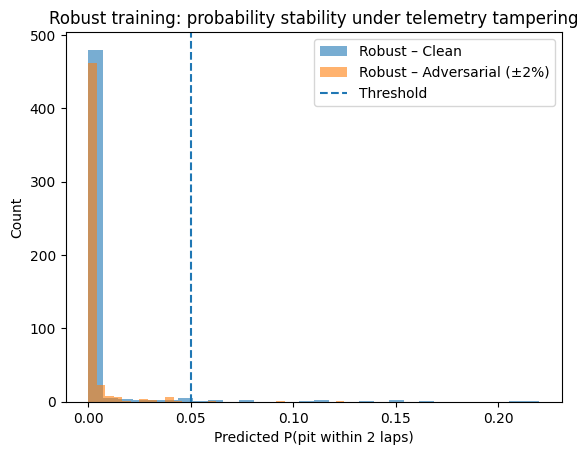

In [12]:
import matplotlib.pyplot as plt

plt.hist(proba_clean, bins=30, alpha=0.6, label="Robust – Clean")
plt.hist(proba_adv, bins=30, alpha=0.6, label="Robust – Adversarial (±2%)")
plt.axvline(THRESHOLD, linestyle="--", label="Threshold")
plt.legend()
plt.title("Robust training: probability stability under telemetry tampering")
plt.xlabel("Predicted P(pit within 2 laps)")
plt.ylabel("Count")
plt.show()


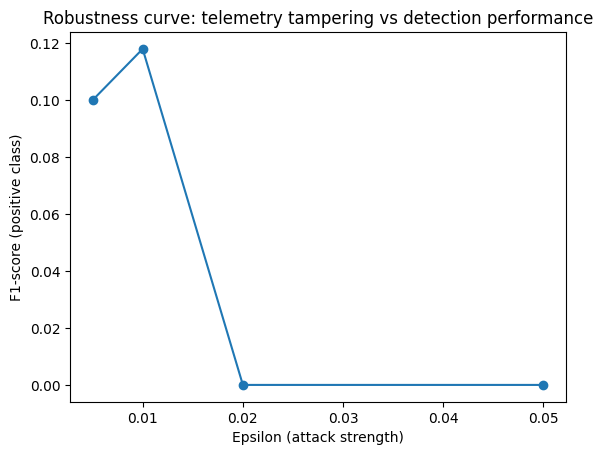

In [16]:
eps_list = [0.005, 0.01, 0.02, 0.05]
f1_list  = [0.100, 0.118, 0.000, 0.000]
pos_list = [17, 14, 3, 2]

plt.plot(eps_list, f1_list, marker="o")
plt.xlabel("Epsilon (attack strength)")
plt.ylabel("F1-score (positive class)")
plt.title("Robustness curve: telemetry tampering vs detection performance")
plt.show()
